In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Cargar el dataset
data_1 = pd.read_csv('2023-03-08 Precios Casas RM.csv')
data_2 = pd.read_csv('2023-07-18 Propiedades Web Scrape.csv')
data_1.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


In [4]:
data_2.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,129884400,3600.0,158396.0,Lampa,AvenidaLaHacienda,3.0,2.0,68.0,221.0,1.0,7850612,Behouse
1,130000000,3603.0,158537.0,Buin,Villaseca,5.0,3.0,150.0,190.0,2.0,10081485,NaN
2,172998805,4795.0,210974.0,PuenteAlto,BarrioAustria,4.0,3.0,90.0,182.0,3.0,10257247,Bissac
3,135296250,3750.0,164995.0,Buin,ComercianteArmandoPérezCarrasco,3.0,2.0,85.0,175.0,1.0,20153043,Ambiento Propiedades
4,195000000,5405.0,237805.0,QuintaNormal,Hostos,3.0,3.0,130.0,402.0,1.0,16669338,Puntoinmobiliario.cl


In [5]:
# Realizar un análisis exploratorio de los datos
print(data_1.info())
print(data_1.describe())

<class 'pandas.DataFrame'>
RangeIndex: 7779 entries, 0 to 7778
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   7779 non-null   int64  
 1   Price_UF    7779 non-null   int64  
 2   Price_USD   7779 non-null   int64  
 3   Comuna      7779 non-null   str    
 4   Ubicacion   7779 non-null   str    
 5   Dorms       7779 non-null   int64  
 6   Baths       7714 non-null   float64
 7   Built Area  7533 non-null   float64
 8   Total Area  7571 non-null   float64
 9   Parking     5489 non-null   float64
 10  id          7779 non-null   int64  
 11  Realtor     7184 non-null   str    
dtypes: float64(4), int64(5), str(3)
memory usage: 729.4 KB
None
          Price_CLP       Price_UF     Price_USD        Dorms        Baths  \
count  7.779000e+03    7779.000000  7.779000e+03  7779.000000  7714.000000   
mean   3.642481e+08   10234.571153  4.536091e+05     3.994087     2.653746   
std    3.868810e+08   10870.491

In [6]:
print(data_2.info())
print(data_2.describe())

<class 'pandas.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   9291 non-null   int64  
 1   Price_UF    9291 non-null   float64
 2   Price_USD   9291 non-null   float64
 3   Comuna      9291 non-null   str    
 4   Ubicacion   9291 non-null   str    
 5   Dorms       9202 non-null   float64
 6   Baths       9138 non-null   float64
 7   Built Area  9013 non-null   float64
 8   Total Area  9057 non-null   float64
 9   Parking     6371 non-null   float64
 10  id          9291 non-null   int64  
 11  Realtor     8125 non-null   str    
dtypes: float64(7), int64(2), str(3)
memory usage: 871.2 KB
None
          Price_CLP       Price_UF     Price_USD        Dorms        Baths  \
count  9.291000e+03    9291.000000  9.291000e+03  9202.000000  9138.000000   
mean   3.925134e+08   10879.276827  4.786749e+05     4.027059     2.749726   
std    4.036515e+08   11187.989

In [7]:
# Revisar las etiquetas de las columnas
print(data_1.columns)
print(data_2.columns)

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='str')
Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='str')


In [8]:
# Juntar los datasets en uno solo y eliminar los datos nulos
data = pd.concat([data_1, data_2], ignore_index=True)
data.dropna(inplace=True)

In [9]:
# Revisar data final
print(data.info())
print(data.describe())
data

<class 'pandas.DataFrame'>
Index: 10348 entries, 1 to 17068
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   10348 non-null  int64  
 1   Price_UF    10348 non-null  float64
 2   Price_USD   10348 non-null  float64
 3   Comuna      10348 non-null  str    
 4   Ubicacion   10348 non-null  str    
 5   Dorms       10348 non-null  float64
 6   Baths       10348 non-null  float64
 7   Built Area  10348 non-null  float64
 8   Total Area  10348 non-null  float64
 9   Parking     10348 non-null  float64
 10  id          10348 non-null  int64  
 11  Realtor     10348 non-null  str    
dtypes: float64(7), int64(2), str(3)
memory usage: 1.0 MB
None
          Price_CLP       Price_UF     Price_USD         Dorms         Baths  \
count  1.034800e+04   10348.000000  1.034800e+04  10348.000000  10348.000000   
mean   4.093347e+08   11416.268264  5.039853e+05      4.017298      2.844898   
std    4.029806e+08   11238.52

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
1,105000000,2950.0,130760.0,PedroAguirreCerda,Rucalhue,2.0,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600.0,159557.0,EstaciónCentral,AvenidaLasParcelas,3.0,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107.0,93400.0,Colina,PasajeGonzaloRojas,3.0,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489.0,66002.0,Colina,HernánDíazArrieta2820,2.0,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades
6,75000000,2107.0,93400.0,Colina,GabrielaMistral/PabloNeruda,3.0,1.0,70.0,80.0,2.0,11688480,Patricio Gajardo propiedades
...,...,...,...,...,...,...,...,...,...,...,...,...
17061,211062150,5850.0,257393.0,Quilicura,EduardoMaira,3.0,2.0,145.0,247.0,4.0,8176688,Margarita Leiva Catalan
17062,88000000,2439.0,107317.0,Pudahuel,Elarce,4.0,1.0,38.0,62.0,1.0,8454097,Paula Vivanco Arenas
17065,80000000,2217.0,97561.0,PuenteAlto,LasAvestruces0352,2.0,1.0,75.0,100.0,2.0,7817190,Margarita Leiva Catalan
17067,3788295000,105000.0,4619872.0,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5.0,7.0,460.0,4925.0,8.0,6032811,Tsi Property


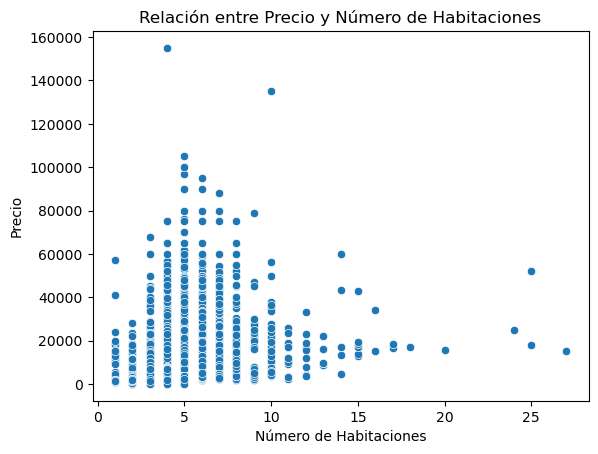

In [11]:
# Relación entre el precio y el número de habitaciones
sns.scatterplot(x='Dorms', y='Price_UF', data=data_1)
plt.title('Relación entre Precio y Número de Habitaciones')
plt.xlabel('Número de Habitaciones')
plt.ylabel('Precio')
plt.show()

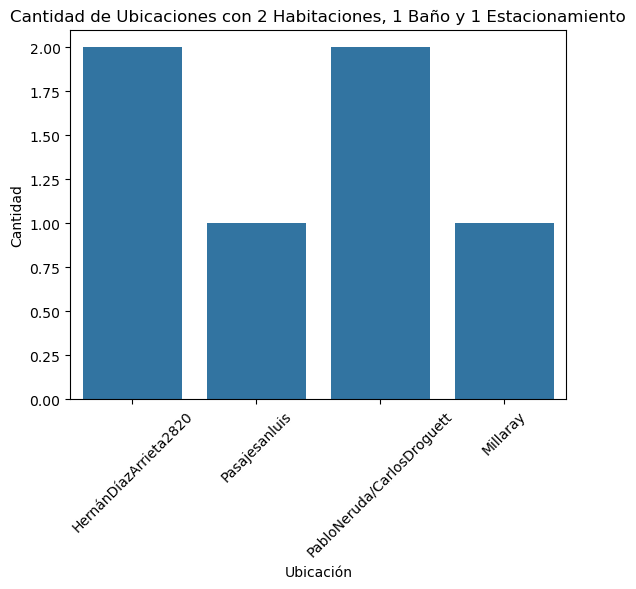

In [17]:
#Grafico de la cantidad de ubicaciones con 2 habitaciones, 1 baño, un estacionamiento y que este en la comuna de colina en el dataset
sns.countplot(x='Ubicacion', data=data[(data['Dorms'] == 2) & (data['Baths'] == 1) & (data['Parking'] == 1) & (data['Comuna'] == 'Colina')])
plt.title('Cantidad de Ubicaciones con 2 Habitaciones, 1 Baño y 1 Estacionamiento')
plt.xlabel('Ubicación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# Uso de Modelos Lineales

In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
X = data.drop(columns=['Price_UF'])
y = data['Price_UF']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8278, 11), (2070, 11), (8278,), (2070,))